# Lumpy forecasting pipeline

**Horizon:** An 18-month evaluation window, refreshed monthly.  
**Lead:** Two months ahead. A forecast issued in January is evaluated against March actual demand.  
**Accuracy:** Each SKU is scored using the mean WMAPE from every complete, overlapping three-month total in the 18-month window.

The selection objective is ordered: maximise SKUs below 50% first, then below 70%, then below 100%. Portfolio WMAPE is reported but is not used to choose the forecasting route.


## 1. Import libraries

The forecasting models are called from `src` when needed.


In [1]:
# Import the libraries.
from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np
import pandas as pd
from IPython.display import display


# Find the repository from either its root or the notebooks folder.
def find_project_root():
    """Return the nearest parent containing the forecasting source code."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "src/lumpy_forecasting.py").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository.")


# Add the reusable model code to the Python import path.
PROJECT_ROOT = find_project_root()
SOURCE_ROOT = PROJECT_ROOT / "src"
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

import lumpy_forecasting as lf
import lumpy_monthly_evaluation as evaluation
import lumpy_monthly_pipeline as monthly_pipeline
import lumpy_transparent_pipeline as transparent_pipeline


# Keep the forecasting and evaluation contract in one visible configuration.
CONFIG = monthly_pipeline.PipelineConfig(
    forecast_horizon_months=18,
    forecast_lead_months=2,
    rolling_wmape_months=3,
    train_months=48,
    minimum_train_months=18,
    random_state=42,
)

# Monthly checkpoints allow a long model run to resume after interruption.
CHECKPOINT_DIRECTORY = PROJECT_ROOT / ".cache/lumpy_forecasting_submission_run"
RUN_CONFIG = transparent_pipeline.CandidateRunConfig(
    random_state=CONFIG.random_state,
    xgb_estimators=180,
    checkpoint_directory=CHECKPOINT_DIRECTORY,
)

contract = pd.DataFrame(
    [
        {"setting": "Evaluation window", "value": "18 months"},
        {"setting": "Forecast lead", "value": "2 months (January to March)"},
        {"setting": "Forecast refresh", "value": "Every month"},
        {"setting": "Accuracy measure", "value": "Overlapping 3-month rolling WMAPE"},
        {"setting": "Selection priority", "value": "Under 50%, then under 70%, then under 100%"},
    ]
)
display(contract)
print("Project root:", PROJECT_ROOT)


,setting,value
0,Evaluation window,18 months
1,Forecast lead,2 months (January to March)
2,Forecast refresh,Every month
3,Accuracy measure,Overlapping 3-month rolling WMAPE
4,Selection priority,"Under 50%, then under 70%, then under 100%"


Project root: D:\Lumpy_Fellas-\Inchscape Repo


## 2. Workflow

The diagram shows how the data moves through classification, forecasting, model selection and evaluation.


findfont: Failed to find font weight semibold, now using 700.


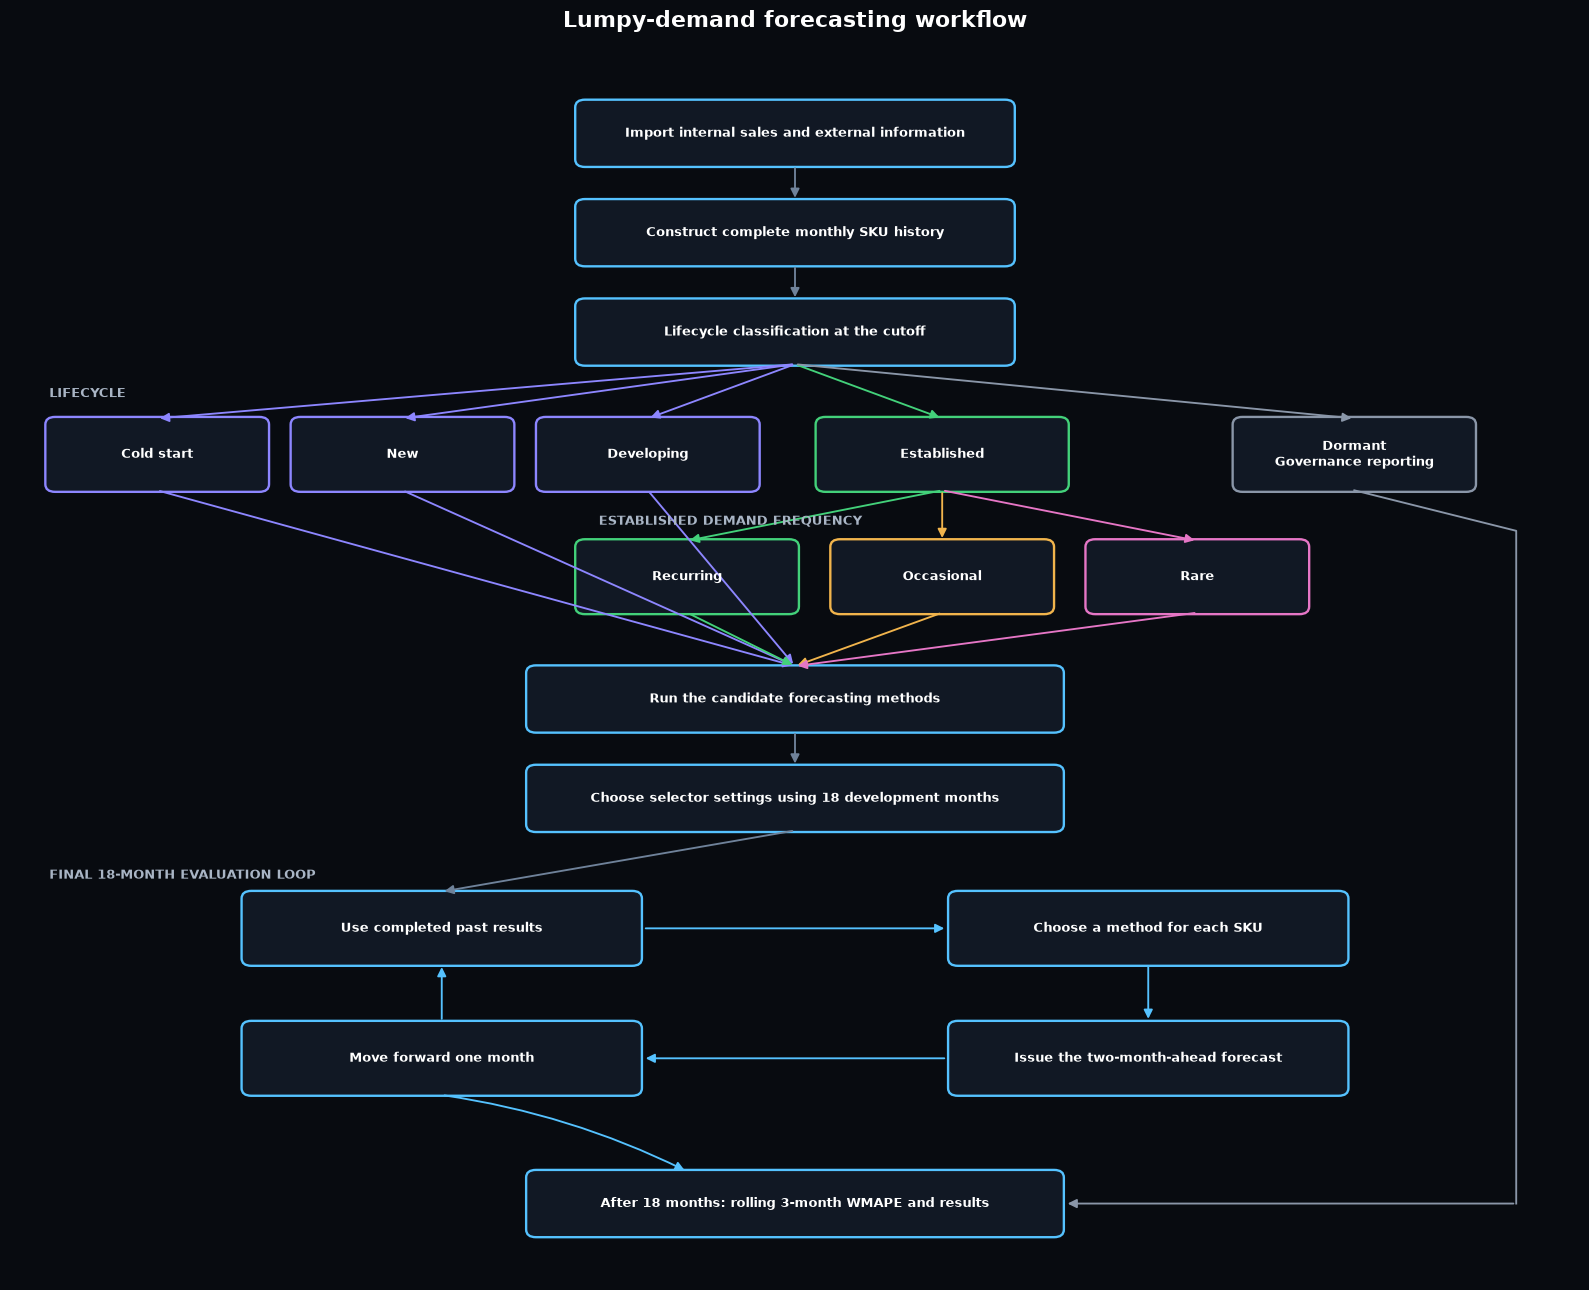

In [2]:
# Draw the lifecycle split, established-SKU split and monthly selection loop.
fig, ax = plt.subplots(figsize=(16, 13), facecolor="#080B10")
ax.set_facecolor("#080B10")
ax.set_xlim(0, 16)
ax.set_ylim(-3.0, 13.1)
ax.axis("off")

nodes = {
    "data": (8.0, 12.0, 4.4, 0.8, "Import internal sales and external information", "#55C2FF"),
    "history": (8.0, 10.7, 4.4, 0.8, "Construct complete monthly SKU history", "#55C2FF"),
    "classification": (8.0, 9.4, 4.4, 0.8, "Lifecycle classification at the cutoff", "#55C2FF"),
    "cold": (1.5, 7.8, 2.2, 0.9, "Cold start", "#8D86FF"),
    "new": (4.0, 7.8, 2.2, 0.9, "New", "#8D86FF"),
    "developing": (6.5, 7.8, 2.2, 0.9, "Developing", "#8D86FF"),
    "established": (9.5, 7.8, 2.5, 0.9, "Established", "#43D17A"),
    "dormant": (13.7, 7.8, 2.4, 0.9, "Dormant\nGovernance reporting", "#8A96A8"),
    "recurring": (6.9, 6.2, 2.2, 0.9, "Recurring", "#43D17A"),
    "occasional": (9.5, 6.2, 2.2, 0.9, "Occasional", "#F1B44C"),
    "rare": (12.1, 6.2, 2.2, 0.9, "Rare", "#E676C6"),
    "candidates": (8.0, 4.6, 5.4, 0.8, "Run the candidate forecasting methods", "#55C2FF"),
    "development": (8.0, 3.3, 5.4, 0.8, "Choose selector settings using 18 development months", "#55C2FF"),
    "past": (4.4, 1.6, 4.0, 0.9, "Use completed past results", "#55C2FF"),
    "select": (11.6, 1.6, 4.0, 0.9, "Choose a method for each SKU", "#55C2FF"),
    "forecast": (11.6, -0.1, 4.0, 0.9, "Issue the two-month-ahead forecast", "#55C2FF"),
    "advance": (4.4, -0.1, 4.0, 0.9, "Move forward one month", "#55C2FF"),
    "results": (8.0, -2.0, 5.4, 0.8, "After 18 months: rolling 3-month WMAPE and results", "#55C2FF"),
}


# Add one labelled box for each stage or SKU route.
for x, y, width, height, label, colour in nodes.values():
    box = FancyBboxPatch(
        (x - width / 2, y - height / 2),
        width,
        height,
        boxstyle="round,pad=0.04,rounding_size=0.10",
        facecolor="#111824",
        edgecolor=colour,
        linewidth=1.7,
    )
    ax.add_patch(box)
    ax.text(
        x,
        y,
        label,
        ha="center",
        va="center",
        color="white",
        fontsize=9.5,
        weight="semibold",
    )

# Label the two classification levels and the repeating evaluation process.
ax.text(0.4, 8.55, "LIFECYCLE", color="#A9B5C5", fontsize=9, weight="bold")
ax.text(
    6.0,
    6.88,
    "ESTABLISHED DEMAND FREQUENCY",
    color="#A9B5C5",
    fontsize=9,
    weight="bold",
)
ax.text(
    0.4,
    2.25,
    "FINAL 18-MONTH EVALUATION LOOP",
    color="#A9B5C5",
    fontsize=9,
    weight="bold",
)


# Connect the stages in the same order used below.
def workflow_arrow(start, end, colour="#6F829A", curve=0.0):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=13,
        color=colour,
        linewidth=1.35,
        connectionstyle=f"arc3,rad={curve}",
    )
    ax.add_patch(arrow)


workflow_arrow((8.0, 11.58), (8.0, 11.12))
workflow_arrow((8.0, 10.28), (8.0, 9.82))

# First split every SKU by lifecycle.
for lifecycle_x, colour in [
    (1.5, "#8D86FF"),
    (4.0, "#8D86FF"),
    (6.5, "#8D86FF"),
    (9.5, "#43D17A"),
    (13.7, "#8A96A8"),
]:
    workflow_arrow((8.0, 8.98), (lifecycle_x, 8.27), colour)

# Split established SKUs again by demand frequency.
for frequency_x, colour in [
    (6.9, "#43D17A"),
    (9.5, "#F1B44C"),
    (12.1, "#E676C6"),
]:
    workflow_arrow((9.5, 7.33), (frequency_x, 6.67), colour)

# Send every forecastable category into the candidate methods.
for category_x, category_y, colour in [
    (1.5, 7.33, "#8D86FF"),
    (4.0, 7.33, "#8D86FF"),
    (6.5, 7.33, "#8D86FF"),
    (6.9, 5.73, "#43D17A"),
    (9.5, 5.73, "#F1B44C"),
    (12.1, 5.73, "#E676C6"),
]:
    workflow_arrow((category_x, category_y), (8.0, 5.03), colour)

workflow_arrow((8.0, 4.18), (8.0, 3.72))
workflow_arrow((8.0, 2.88), (4.4, 2.08))

# Repeat the monthly selection process across the final 18-month window.
workflow_arrow((6.45, 1.6), (9.55, 1.6), "#55C2FF")
workflow_arrow((11.6, 1.13), (11.6, 0.38), "#55C2FF")
workflow_arrow((9.55, -0.1), (6.45, -0.1), "#55C2FF")
workflow_arrow((4.4, 0.38), (4.4, 1.13), "#55C2FF")
workflow_arrow((4.4, -0.58), (6.9, -1.58), "#55C2FF", curve=-0.08)

# Dormant SKUs bypass accuracy scoring but remain in the final governance output.
ax.plot(
    [13.7, 15.35, 15.35],
    [7.33, 6.8, -2.0],
    color="#8A96A8",
    linewidth=1.35,
)
workflow_arrow((15.35, -2.0), (10.75, -2.0), "#8A96A8")

ax.set_title(
    "Lumpy-demand forecasting workflow",
    color="white",
    fontsize=16,
    weight="bold",
    pad=16,
)
plt.tight_layout()
plt.show()


## 3. Import data

The workflow starts with two source datasets:

1. `data/processed/all_sku_history/collision_sales_lumpy.csv` contains the internal monthly sales history for the 690 lumpy SKUs.
2. `data/external/monthly_external_features.csv` contains the monthly external information prepared by the external-features notebook.

Both sources cover January 2021 to April 2026.


In [3]:
# Import the internal sales history and monthly external information.
sales, external_features = lf.load_lumpy_inputs(
    PROJECT_ROOT,
    monthly_pipeline.model_config(CONFIG),
)

# Confirm the expected source periods before any model is fitted.
source_check = pd.DataFrame(
    [
        {
            "source": "Internal lumpy sales history",
            "rows": len(sales),
            "skus": sales.sku_id.nunique(),
            "first_month": sales.month.min(),
            "last_month": sales.month.max(),
            "months": sales.month.nunique(),
        },
        {
            "source": "Monthly external information",
            "rows": len(external_features),
            "skus": pd.NA,
            "first_month": external_features.date.min(),
            "last_month": external_features.date.max(),
            "months": external_features.date.nunique(),
        },
    ]
)
display(source_check)
assert sales.sku_id.nunique() == 690
assert sales.month.nunique() == 64
assert external_features.date.nunique() == 64


,source,rows,skus,first_month,last_month,months
0,Internal lumpy sales history,38909,690,2021-01-01,2026-04-01,64
1,Monthly external information,64,<NA>,2021-01-01,2026-04-01,64


## 4. Construct the complete monthly SKU history

Each SKU receives one row for every month from its first observation onward. Missing demand months are recorded as zero, while static product descriptions are carried across the SKU history. This gives every model a consistent monthly structure.

Two model frames are prepared from the same sales history. The internal frame excludes external signals. The external frame adds only the external fields that the feature pipeline marks for model use.


In [4]:
# Build the internal model frame used by classical and history-only methods.
internal_config = replace(
    monthly_pipeline.model_config(CONFIG),
    external_mode="off",
)
model_data, _ = lf.build_lumpy_model_frame(
    sales,
    external_features,
    internal_config,
)
model_data["month"] = pd.to_datetime(model_data["month"])

# Build the external model frame used by the external regression candidates.
external_config = replace(
    monthly_pipeline.model_config(CONFIG),
    external_mode="selected",
)
model_data_external, external_inventory = lf.build_lumpy_model_frame(
    sales,
    external_features,
    external_config,
)
model_data_external["month"] = pd.to_datetime(model_data_external["month"])

monthly_history_check = pd.DataFrame(
    [
        {
            "prepared_frame": "Internal history",
            "rows": len(model_data),
            "skus": model_data.sku_id.nunique(),
            "months": model_data.month.nunique(),
            "external_features": 0,
        },
        {
            "prepared_frame": "History with selected external information",
            "rows": len(model_data_external),
            "skus": model_data_external.sku_id.nunique(),
            "months": model_data_external.month.nunique(),
            "external_features": len(external_inventory),
        },
    ]
)
display(monthly_history_check)
display(external_inventory)


,prepared_frame,rows,skus,months,external_features
0,Internal history,38909,690,64,0
1,History with selected external information,38909,690,64,6


,source_column,feature,usage
0,min_temperature,external_source__min_temperature,model_lag_source
1,max_wind_gust,external_source__max_wind_gust,model_lag_source
2,days_in_month,external_known__days_in_month,known_ahead
3,weekend_days,external_known__weekend_days,known_ahead
4,public_holidays,external_known__public_holidays,known_ahead
5,working_days,external_known__working_days,known_ahead


## 5. SKU classification

Classification is fixed before the final 18-month evaluation window. Only history available at the cutoff is used.

Established SKUs are divided into recurring, occasional and rare demand. Cold-start, new and developing SKUs retain their lifecycle category. Dormant SKUs remain in governance reporting but are excluded from the accuracy results. SKUs with no positive demand during evaluation are also excluded because their WMAPE cannot be scored.


In [5]:
# Create adjacent development and final evaluation periods.
development_months, holdout_months, monthly_jobs = (
    monthly_pipeline.evaluation_calendar(model_data, CONFIG)
)

# Classify every SKU using only history available at the classification cutoff.
population = monthly_pipeline.classify_population(
    sales=sales,
    model_data=model_data,
    holdout_months=holdout_months,
    config=CONFIG,
)

classification_summary = (
    population.groupby(["lifecycle_tier", "segment"], dropna=False)
    .agg(
        all_skus=("sku_id", "nunique"),
        reporting_skus=("reporting_eligible", "sum"),
    )
    .reset_index()
)
display(classification_summary)
print("Classification cutoff:", population.classification_cutoff.iloc[0])
print("Reporting SKUs:", int(population.reporting_eligible.sum()))


,lifecycle_tier,segment,all_skus,reporting_skus
0,cold_start,cold_start,32,32
1,developing,developing,27,25
2,dormant,dormant,40,0
3,established,occasional,129,115
4,established,rare,70,44
5,established,recurring,349,347
6,new,new,43,43


Classification cutoff: 2024-09-01 00:00:00
Reporting SKUs: 606


## 6. Create the monthly forecast schedule

Every target month has a forecast date exactly two months earlier. January information forecasts March; February information forecasts April; March information forecasts May.

The schedule moves forward by one month to simulate how forecasts would be refreshed in practice. It contains 18 development targets followed by the final 18-month evaluation window.


In [6]:
# Label each monthly job as development or final evaluation.
monthly_jobs = monthly_jobs.copy()
monthly_jobs["period"] = np.where(
    monthly_jobs.target_month.isin(development_months),
    "development",
    "final_evaluation",
)

# Display the start and end of both parts of the schedule.
calendar_examples = pd.concat(
    [
        monthly_jobs.loc[monthly_jobs.period.eq("development")].head(2),
        monthly_jobs.loc[monthly_jobs.period.eq("development")].tail(2),
        monthly_jobs.loc[monthly_jobs.period.eq("final_evaluation")].head(2),
        monthly_jobs.loc[monthly_jobs.period.eq("final_evaluation")].tail(2),
    ],
    ignore_index=True,
)
display(
    calendar_examples[
        [
            "period",
            "forecast_origin",
            "target_month",
            "train_start",
            "train_end",
            "observed_train_months",
        ]
    ]
)
assert len(monthly_jobs) == 36
assert monthly_jobs.forecast_lead_months.eq(2).all()


,period,forecast_origin,target_month,train_start,train_end,observed_train_months
0,development,2023-03-01,2023-05-01,2021-01-01,2023-03-01,27
1,development,2023-04-01,2023-06-01,2021-01-01,2023-04-01,28
2,development,2024-07-01,2024-09-01,2021-01-01,2024-07-01,43
3,development,2024-08-01,2024-10-01,2021-01-01,2024-08-01,44
4,final_evaluation,2024-09-01,2024-11-01,2021-01-01,2024-09-01,45
5,final_evaluation,2024-10-01,2024-12-01,2021-01-01,2024-10-01,46
6,final_evaluation,2026-01-01,2026-03-01,2022-02-01,2026-01-01,48
7,final_evaluation,2026-02-01,2026-04-01,2022-03-01,2026-02-01,48


## 7. Define the forecasting candidates

No single method works best for every lumpy-demand SKU. The catalogue includes intermittent-demand models, recent-history and seasonal averages, regression models, similar-product forecasts, group allocation and blended forecasts.

Each base forecast is assessed at fixed adjustment scales. The adjustment changes the forecast level, not the underlying model or the information available to it.


In [7]:
# Display every base method and the adjusted candidate count.
base_catalogue = transparent_pipeline.candidate_catalogue()
adjusted_catalogue = transparent_pipeline.adjusted_candidate_catalogue()

catalogue_summary = (
    base_catalogue.groupby("method_family")
    .agg(base_methods=("model_key", "nunique"))
    .reset_index()
)
display(catalogue_summary)
display(base_catalogue)
print("Base methods:", base_catalogue.model_key.nunique())
print("Adjusted candidate configurations:", adjusted_catalogue.candidate_id.nunique())


,method_family,base_methods
0,Blended forecasts,6
1,Core and regression models,10
2,Recent-history and seasonal averages,12
3,Regression models,5
4,Similar-product forecasts,6


,model_key,method_family,explanation
0,zero,Core and regression models,Forecast zero demand.
1,sba_croston,Core and regression models,SBA-adjusted Croston intermittent-demand forec...
2,sba_croston_tuned,Core and regression models,SBA Croston with its smoothing value selected ...
3,seasonal_sba_croston,Core and regression models,SBA Croston adjusted for recurring calendar pa...
4,recent_mean_6,Core and regression models,Mean demand from the latest six known months.
5,tsb,Core and regression models,TSB forecast that updates demand size and occu...
6,boosted_sba_hybrid,Core and regression models,Tree-based monthly total forecast blended with...
7,aggregate_allocation,Core and regression models,Forecast a group total and allocate it back to...
8,hurdle_random_forest,Core and regression models,Random-forest occurrence and demand-size forec...
9,hurdle_random_forest__external,Core and regression models,Random-forest forecast with safe external info...


Base methods: 39
Adjusted candidate configurations: 419


## 8. Run every candidate at every monthly origin

Every candidate is run over 36 months. The first 18 months are used to choose the selector settings, while the second 18 months form the final evaluation window.


In [8]:
# Run the complete candidate search for all development and evaluation origins.
candidate_forecasts, candidate_errors = (
    transparent_pipeline.run_complete_candidate_search(
        model_data_internal=model_data,
        model_data_external=model_data_external,
        sales=sales,
        jobs=monthly_jobs,
        pipeline_config=CONFIG,
        run_config=RUN_CONFIG,
    )
)

# Stop immediately if any target month failed.
if not candidate_errors.empty:
    display(candidate_errors)
    raise RuntimeError("One or more monthly candidate runs failed.")

candidate_run_summary = pd.DataFrame(
    [
        {
            "monthly_origins": candidate_forecasts.target_month.nunique(),
            "base_methods_run": candidate_forecasts.model_key.nunique(),
            "forecast_rows": len(candidate_forecasts),
            "first_target": candidate_forecasts.target_month.min(),
            "last_target": candidate_forecasts.target_month.max(),
        }
    ]
)
display(candidate_run_summary)


[1/36] 2023-05: loaded checkpoint


[2/36] 2023-06: loaded checkpoint


[3/36] 2023-07: loaded checkpoint


[4/36] 2023-08: loaded checkpoint


[5/36] 2023-09: loaded checkpoint


...

[34/36] 2026-02: loaded checkpoint


[35/36] 2026-03: loaded checkpoint


[36/36] 2026-04: loaded checkpoint


Complete candidate search finished in 0.0 minutes.


,monthly_origins,base_methods_run,forecast_rows,first_target,last_target
0,36,39,968760,2023-05-01,2026-04-01


## 9. Check the candidate search

The checks below confirm that every base method produced one forecast per SKU and target month. Actual demand is retained for later scoring, but it is not passed to a model or used to select the forecast for that same target month.


In [9]:
# Check candidate coverage and uniqueness before model selection.
expected_candidate_rows = (
    candidate_forecasts.sku_id.nunique()
    * candidate_forecasts.target_month.nunique()
    * candidate_forecasts.model_key.nunique()
)
candidate_checks = pd.DataFrame(
    [
        {
            "check": "18 development and 18 evaluation months completed",
            "passed": candidate_forecasts.target_month.nunique() == 36,
        },
        {
            "check": "All base methods completed",
            "passed": set(base_catalogue.model_key).issubset(
                set(candidate_forecasts.model_key)
            ),
        },
        {
            "check": "No duplicate SKU-month-method rows",
            "passed": not candidate_forecasts.duplicated(
                ["sku_id", "target_month", "model_key"]
            ).any(),
        },
        {
            "check": "Complete candidate grid",
            "passed": len(candidate_forecasts) == expected_candidate_rows,
        },
        {
            "check": "No missing forecasts",
            "passed": not candidate_forecasts.forecast.isna().any(),
        },
    ]
)
display(candidate_checks)
assert candidate_checks.passed.all()


,check,passed
0,18 development and 18 evaluation months completed,True
1,All base methods completed,True
2,No duplicate SKU-month-method rows,True
3,Complete candidate grid,True
4,No missing forecasts,True


## 10. Tune the monthly selector on development data

The selector answers two questions:

1. How many recent completed months should be used to compare methods?
2. How many of the strongest category-level candidates should remain available for individual SKU selection?

Every combination is tested on the second half of the development period. Candidates are ranked by the number of SKUs below 50%, then below 70%, then below 100%. The final 18-month evaluation period is not used to choose these settings.


In [10]:
# Add the frozen category to the candidate rows used for selector development.
candidate_forecasts = candidate_forecasts.merge(
    population[["sku_id", "segment"]],
    on="sku_id",
    how="left",
)

# Tune memory length and candidate-pool size separately for each category.
selector_locks, selector_development_forecasts = (
    transparent_pipeline.tune_selector_by_category(
        candidates=candidate_forecasts,
        population=population,
        development_months=development_months,
        forecast_lead_months=CONFIG.forecast_lead_months,
    )
)

display(
    selector_locks[
        [
            "segment",
            "memory_months",
            "candidate_pool",
            "positive_skus",
            "under_50",
            "under_70",
            "under_100",
            "median_wmape",
        ]
    ]
)


,segment,memory_months,candidate_pool,positive_skus,under_50,under_70,under_100,median_wmape
0,cold_start,12,1,3,0,0,0,100.000000
1,developing,9,64,22,13,21,22,47.260273
2,new,3,1,41,32,37,40,39.740642
3,occasional,9,64,99,67,79,98,33.274871
4,rare,12,1,37,22,25,36,28.956974
5,recurring,9,1,344,208,307,330,45.528999


## 11. How the selector works each month

For each evaluation target:

1. Keep only candidate results whose actual demand is already known at the forecast date.
2. Rank the candidates within the SKU category using the setting chosen during development.
3. Use each SKU’s completed history to choose among the leading candidates.
4. Issue the forecast, move forward one month and repeat.

The selector can change method as new actual demand becomes available, but it cannot see the actual demand for the month currently being predicted.


In [11]:
# Show when an actual result becomes available to later forecasts.
selector_example = pd.DataFrame(
    [
        {
            "Forecast made in": "January",
            "Predicts": "March",
            "Newest actual known": "January",
            "Can March actual be used?": "No",
        },
        {
            "Forecast made in": "February",
            "Predicts": "April",
            "Newest actual known": "February",
            "Can March actual be used?": "No",
        },
        {
            "Forecast made in": "March",
            "Predicts": "May",
            "Newest actual known": "March",
            "Can March actual be used?": "Yes",
        },
    ]
)
display(selector_example)


,Forecast made in,Predicts,Newest actual known,Can March actual be used?
0,January,March,January,No
1,February,April,February,No
2,March,May,March,Yes


## 12. Apply the selected settings to the final 18 months

The settings chosen in Section 10 remain unchanged during final evaluation. Each target month is forecast in order. An earlier actual result can inform later forecasts only after that result has become available.


In [12]:
# Select the final forecasts one month at a time.
selected_holdout = transparent_pipeline.apply_monthly_selector(
    candidates=candidate_forecasts,
    population=population,
    selector_locks=selector_locks,
    holdout_months=holdout_months,
    forecast_lead_months=CONFIG.forecast_lead_months,
)

selection_summary = (
    selected_holdout.groupby(["segment", "selected_model"])
    .size()
    .rename("times_selected")
    .reset_index()
    .sort_values(["segment", "times_selected"], ascending=[True, False])
)
display(selection_summary.groupby("segment", as_index=False).head(5))
print("Selected monthly forecasts:", len(selected_holdout))


,segment,selected_model,times_selected
4,cold_start,hurdle_random_forest__external__scale_0.50,160
5,cold_start,hurdle_random_forest__scale_0.50,160
2,cold_start,analogue__cold_empirical_bayes5__scale_0.50,64
0,cold_start,aggregate_allocation__scale_0.25,32
1,cold_start,analogue__cold_empirical_bayes15__scale_0.65,32
80,developing,temporal__positive_mean_6__scale_0.65,17
113,developing,xgb_tweedie_depth2_reg10__scale_1.15,16
10,developing,aggregate_allocation__scale_1.15,15
59,developing,hurdle_xgb_threshold_010__external__scale_1.50,15
70,developing,temporal__lag2__scale_0.85,14


Selected monthly forecasts: 10908


## 13. Calculate rolling three-month WMAPE

For every SKU, actual and forecast units are summed over each complete three-month window. The absolute difference between those totals is divided by the actual three-month total. The SKU score is the mean of its valid overlapping window scores across the 18-month evaluation period.


In [13]:
# Build the two final delivery tables from the selected evaluation forecasts.
sku_results, monthly_results = transparent_pipeline.build_delivery_tables(
    selected_holdout
)

print("Reporting SKUs:", sku_results.sku_id.nunique())
print("Monthly actual-versus-forecast rows:", len(monthly_results))
display(sku_results.head())
display(monthly_results.head())


Reporting SKUs: 606
Monthly actual-versus-forecast rows: 10908


,sku_id,segment,sku_rolling_3m_wmape_percent,model,dominant_expert,months_selected
0,0915912051000,cold_start,33.861628,online_expert_router,hurdle_random_forest__external__scale_0.50,5
1,57300M74T00000,cold_start,41.156693,online_expert_router,hurdle_random_forest__external__scale_0.50,5
2,57300M75T00000,cold_start,41.408034,online_expert_router,hurdle_random_forest__external__scale_0.50,5
3,68002M75T00000,cold_start,43.362411,online_expert_router,hurdle_random_forest__external__scale_0.50,5
4,83932M75T000CB,cold_start,45.354410,online_expert_router,hurdle_random_forest__external__scale_0.50,5


,sku_id,month,segment,actual_units,forecast_units,selected_model,sku_rolling_3m_wmape_percent
0,01550M0612A,2024-11-01,rare,0.0,0.303249,ensemble__internal_xgb_mean__scale_1.50,6.8268
1,01550M0612A,2024-12-01,rare,0.0,0.373755,xgb_tweedie_depth3_reg5__external__scale_1.50,6.8268
2,01550M0612A,2025-01-01,rare,0.0,0.368848,xgb_tweedie_depth3_reg5__external__scale_1.50,6.8268
3,01550M0612A,2025-02-01,rare,0.0,0.331829,xgb_tweedie_depth2_reg10__external__scale_1.25,6.8268
4,01550M0612A,2025-03-01,rare,0.0,0.296191,xgb_tweedie_depth3_reg5__external__scale_1.50,6.8268


## 14. Check the selector stability

The table compares the three best selector settings for each SKU category during development. Similar results mean the choice is stable. A large difference would mean the final choice depends more heavily on one particular setting.


In [14]:
# Re-score and rank every selector setting tested during development.
development_setting_rows = []
for (segment, setting_id), group in selector_development_forecasts.groupby(
    ["segment", "setting_id"],
    sort=True,
):
    scored = evaluation.add_complete_rolling_wmape(
        group.assign(model_key="development_selector"),
        sku_column="sku_id",
        month_column="month",
        actual_column="demand",
        rolling_months=CONFIG.rolling_wmape_months,
    )
    per_sku = evaluation.score_skus(
        scored,
        sku_column="sku_id",
        actual_column="demand",
    )
    summary = evaluation.individual_threshold_summary(per_sku)
    development_setting_rows.append(
        {"segment": segment, "setting_id": setting_id, **summary}
    )

development_stability = pd.DataFrame(development_setting_rows).sort_values(
    ["segment", "under_50", "under_70", "under_100", "median_wmape", "setting_id"],
    ascending=[True, False, False, False, True, True],
)
display(development_stability.groupby("segment", as_index=False).head(3))


,segment,setting_id,positive_skus,under_50,under_70,under_100,median_wmape,mean_wmape
0,cold_start,memory_12__pool_1,3,0,0,0,100.000000,100.000000
1,cold_start,memory_12__pool_16,3,0,0,0,100.000000,100.000000
2,cold_start,memory_12__pool_4,3,0,0,0,100.000000,100.000000
31,developing,memory_9__pool_64,22,13,21,22,47.260273,46.762263
29,developing,memory_9__pool_16,22,13,20,22,48.338056,46.670656
30,developing,memory_9__pool_4,22,12,20,22,45.486391,48.067403
36,new,memory_3__pool_1,41,32,37,40,39.740642,41.553032
42,new,memory_5__pool_4,41,29,39,39,39.995460,44.886091
38,new,memory_3__pool_4,41,29,38,41,40.923734,42.442495
63,occasional,memory_9__pool_64,99,67,79,98,33.274871,43.025915


## 15. Final result checks

The checks confirm 18 forecasts per reporting SKU, no duplicate SKU-months, no missing forecasts and one final WMAPE per SKU.


In [15]:
# Validate the complete final result grid.
expected_reporting_skus = int(population.reporting_eligible.sum())
checks = pd.DataFrame(
    [
        {
            "check": "Expected reporting population",
            "passed": sku_results.sku_id.nunique() == expected_reporting_skus,
        },
        {
            "check": "18 months per SKU",
            "passed": monthly_results.groupby("sku_id").month.nunique().eq(18).all(),
        },
        {
            "check": "No duplicate SKU-months",
            "passed": not monthly_results.duplicated(["sku_id", "month"]).any(),
        },
        {
            "check": "No missing actuals or forecasts",
            "passed": not monthly_results[
                ["actual_units", "forecast_units"]
            ].isna().any().any(),
        },
        {
            "check": "One score per SKU",
            "passed": not sku_results.sku_id.duplicated().any(),
        },
    ]
)
display(checks)
assert checks.passed.all()


,check,passed
0,Expected reporting population,True
1,18 months per SKU,True
2,No duplicate SKU-months,True
3,No missing actuals or forecasts,True
4,One score per SKU,True


## 16. Individual-SKU accuracy by category

The under-50, under-70 and under-100 results are cumulative. Each count is shown with the percentage it represents of the reporting SKUs in that category.

The final column reports pooled rolling three-month WMAPE. It combines individual SKU errors without allowing one SKU’s overforecast to cancel another SKU’s underforecast.


In [16]:
# Build one cumulative accuracy row for a category.
def cumulative_accuracy_row(category, group):
    """Return cumulative WMAPE counts and within-category percentages."""
    values = group["sku_rolling_3m_wmape_percent"]
    sku_count = len(group)

    # Convert a count into its percentage of the category population.
    def category_percentage(count):
        return round(100.0 * count / sku_count, 2) if sku_count else np.nan

    under_50 = int(values.lt(50).sum())
    under_70 = int(values.lt(70).sum())
    under_100 = int(values.lt(100).sum())
    above_100 = int(values.ge(100).sum())
    return {
        "category": category,
        "reporting_skus": sku_count,
        "under_50": under_50,
        "under_50_pct": category_percentage(under_50),
        "under_70": under_70,
        "under_70_pct": category_percentage(under_70),
        "under_100": under_100,
        "under_100_pct": category_percentage(under_100),
        "100_or_above": above_100,
        "100_or_above_pct": category_percentage(above_100),
    }


# Calculate cumulative counts and percentages for each category and overall.
band_rows = [
    cumulative_accuracy_row(category, group)
    for category, group in sku_results.groupby("segment", sort=True)
]
band_rows.append(cumulative_accuracy_row("overall", sku_results))
accuracy_bands = pd.DataFrame(band_rows)

# Calculate pooled rolling WMAPE for each category.
_, category_pooled = evaluation.pooled_group_rolling_wmape(
    forecasts=monthly_results,
    group_columns=["segment"],
    month_column="month",
    actual_column="actual_units",
    forecast_column="forecast_units",
    rolling_months=CONFIG.rolling_wmape_months,
)
category_pooled = category_pooled.rename(
    columns={
        "segment": "category",
        "rolling_3m_wmape_percent": "pooled_rolling_3m_wmape_percent",
    }
)[["category", "pooled_rolling_3m_wmape_percent"]]
accuracy_bands = accuracy_bands.merge(category_pooled, on="category", how="left")

# Calculate the same pooled measure across the complete reporting population.
_, overall_pooled = evaluation.pooled_group_rolling_wmape(
    forecasts=monthly_results.assign(reporting_population="overall"),
    group_columns=["reporting_population"],
    month_column="month",
    actual_column="actual_units",
    forecast_column="forecast_units",
    rolling_months=CONFIG.rolling_wmape_months,
)
overall_pooled_value = float(overall_pooled.loc[0, "rolling_3m_wmape_percent"])
accuracy_bands.loc[
    accuracy_bands.category.eq("overall"),
    "pooled_rolling_3m_wmape_percent",
] = overall_pooled_value
accuracy_bands["pooled_rolling_3m_wmape_percent"] = accuracy_bands[
    "pooled_rolling_3m_wmape_percent"
].round(2)

display(accuracy_bands)
print(f"Overall pooled rolling 3-month WMAPE: {overall_pooled_value:.2f}%")


,category,reporting_skus,under_50,under_50_pct,under_70,under_70_pct,under_100,under_100_pct,100_or_above,100_or_above_pct,pooled_rolling_3m_wmape_percent
0,cold_start,32,5,15.62,22,68.75,25,78.12,7,21.88,93.50
1,developing,25,10,40.00,17,68.00,20,80.00,5,20.00,61.61
2,new,43,9,20.93,20,46.51,34,79.07,9,20.93,63.20
3,occasional,115,72,62.61,95,82.61,108,93.91,7,6.09,166.24
4,rare,44,27,61.36,36,81.82,44,100.00,0,0.00,199.27
5,recurring,347,211,60.81,323,93.08,346,99.71,1,0.29,78.51
6,overall,606,334,55.12,513,84.65,577,95.21,29,4.79,85.48


Overall pooled rolling 3-month WMAPE: 85.48%


## 17. Full lumpy-demand history


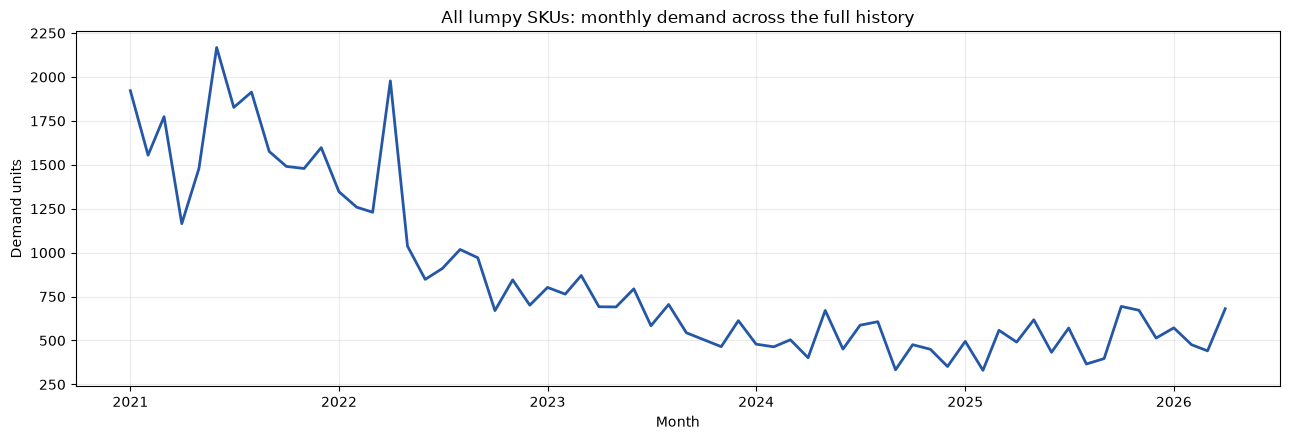

In [17]:
# Plot total monthly demand across the complete available history.
history = (
    model_data.groupby("month", as_index=False)["demand"].sum()
    .sort_values("month")
)
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(history.month, history.demand, color="#2457A6", linewidth=2)
ax.set_title("All lumpy SKUs: monthly demand across the full history")
ax.set_ylabel("Demand units")
ax.set_xlabel("Month")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 18. All-SKU actual versus forecast


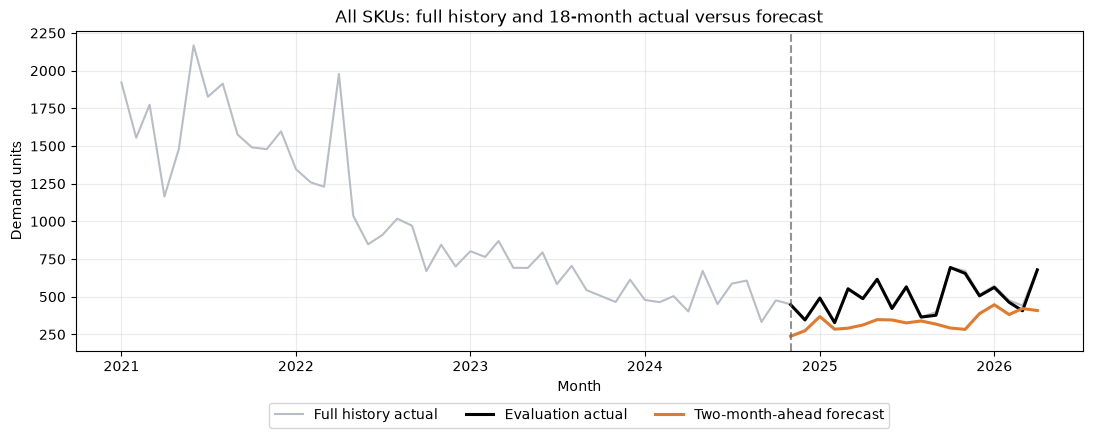

In [18]:
# Add the final 18-month actual-versus-forecast result to the full history.
portfolio = monthly_results.groupby("month", as_index=False).agg(
    actual_units=("actual_units", "sum"),
    forecast_units=("forecast_units", "sum"),
)
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(
    history.month,
    history.demand,
    color="#B8BDC7",
    label="Full history actual",
)
ax.plot(
    portfolio.month,
    portfolio.actual_units,
    color="black",
    linewidth=2.2,
    label="Evaluation actual",
)
ax.plot(
    portfolio.month,
    portfolio.forecast_units,
    color="#E07A2D",
    linewidth=2.2,
    label="Two-month-ahead forecast",
)
ax.axvline(portfolio.month.min(), color="#666666", linestyle="--", alpha=0.7)
ax.set_title("All SKUs: full history and 18-month actual versus forecast")
ax.set_ylabel("Demand units")
ax.set_xlabel("Month")
ax.grid(alpha=0.25)
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.14))
fig.subplots_adjust(bottom=0.24)
plt.show()


## 19. Four best-performing SKUs


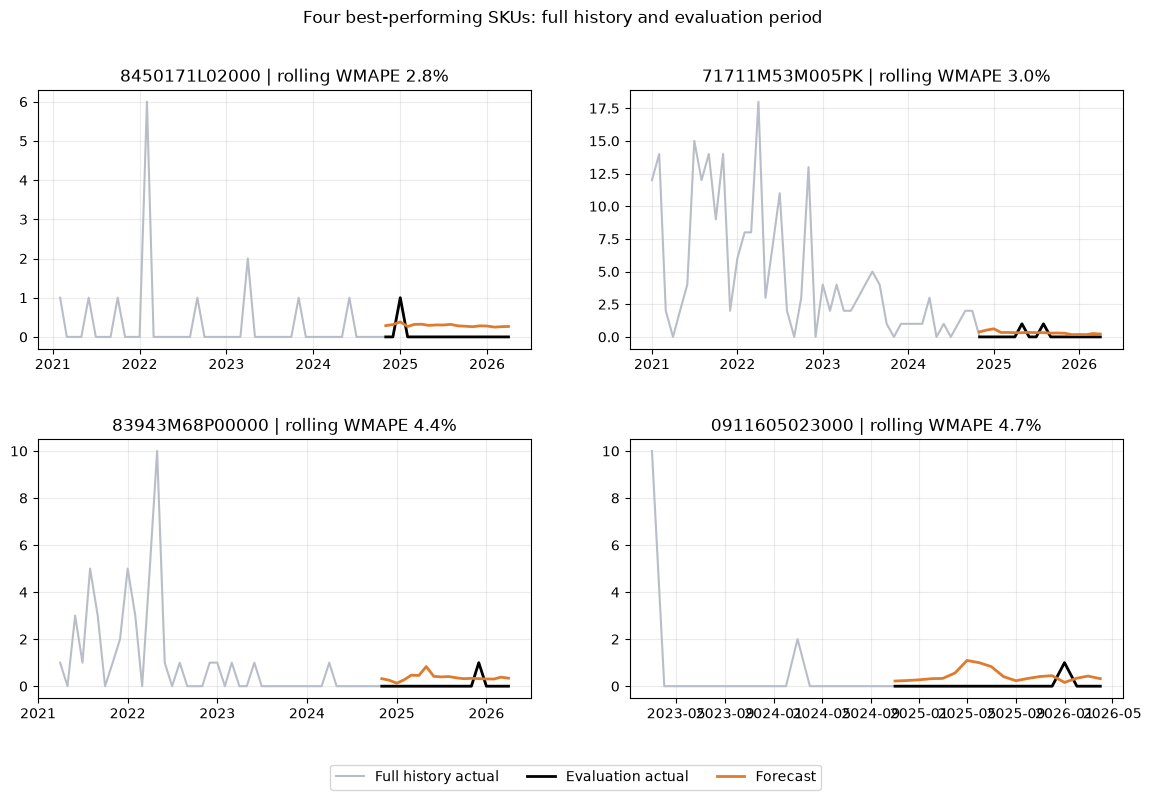

In [19]:
# Plot full history and evaluation forecasts for the four lowest-WMAPE SKUs.
best_ids = sku_results.nsmallest(
    4, "sku_rolling_3m_wmape_percent"
).sku_id.tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for axis, sku_id in zip(axes.flat, best_ids):
    historical = model_data.loc[model_data.sku_id.eq(sku_id)]
    forecast = monthly_results.loc[monthly_results.sku_id.eq(sku_id)]
    axis.plot(
        historical.month,
        historical.demand,
        color="#B8BDC7",
        label="Full history actual",
    )
    axis.plot(
        forecast.month,
        forecast.actual_units,
        color="black",
        linewidth=2,
        label="Evaluation actual",
    )
    axis.plot(
        forecast.month,
        forecast.forecast_units,
        color="#E07A2D",
        linewidth=2,
        label="Forecast",
    )
    score = sku_results.loc[
        sku_results.sku_id.eq(sku_id),
        "sku_rolling_3m_wmape_percent",
    ].iloc[0]
    axis.set_title(f"{sku_id} | rolling WMAPE {score:.1f}%")
    axis.grid(alpha=0.25)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=3, loc="lower center")
fig.suptitle(
    "Four best-performing SKUs: full history and evaluation period",
    y=0.98,
)
fig.subplots_adjust(top=0.88, bottom=0.12, hspace=0.35)
plt.show()


## 20. Export the completed forecasting results

The two CSVs are created only after candidate generation, development tuning, final monthly selection and accuracy calculation have completed:

1. one row per reporting SKU with its rolling three-month WMAPE and most-used model;
2. one row per reporting SKU-month with actual demand, forecast demand and selected model.


In [20]:
# Write only the two final delivery tables.
sku_output_path = PROJECT_ROOT / "results/lumpy_sku_wmape_and_model.csv"
monthly_output_path = (
    PROJECT_ROOT / "results/lumpy_monthly_actual_vs_forecast.csv"
)
sku_output_path.parent.mkdir(parents=True, exist_ok=True)
sku_results.to_csv(sku_output_path, index=False)
monthly_results.to_csv(monthly_output_path, index=False)

exports = pd.DataFrame(
    [
        {
            "file": str(sku_output_path.relative_to(PROJECT_ROOT)),
            "purpose": "One rolling WMAPE and most-used model per reporting SKU",
            "rows": len(sku_results),
        },
        {
            "file": str(monthly_output_path.relative_to(PROJECT_ROOT)),
            "purpose": "Month-by-month actual versus forecast for each reporting SKU",
            "rows": len(monthly_results),
        },
    ]
)
display(exports)


,file,purpose,rows
0,results\lumpy_sku_wmape_and_model.csv,One rolling WMAPE and most-used model per repo...,606
1,results\lumpy_monthly_actual_vs_forecast.csv,Month-by-month actual versus forecast for each...,10908
